# Deep Learning Model - YouTube Sentiment Classification

Fine-tunes **DistilBERT** (`distilbert-base-uncased`) for 3-class sentiment using PyTorch and the Spark deep-learning tooling from the practical classes: `TorchDistributor` for training and `predict_batch_udf` for inference.

**Pipeline:**
```
Spark  ->  stratified split  ->  Parquet                       (Section 1)
TorchDistributor  ->  unfreeze last 3 blocks  ->  state_dict   (Section 2)
reconstruct model on driver  ->  save                          (Section 3)
predict_batch_udf  ->  Spark-native inference                  (Section 4)
Spark SQL + MulticlassClassificationEvaluator                  (Section 5)
```

**Why this design.** The lab teaches two reusable patterns: `TorchDistributor` (train a self-contained PyTorch function on Spark, get a `state_dict` back on the driver) and `predict_batch_udf` (load a model once per worker, score rows in batches). We apply both here. The only step beyond the lab is **layer unfreezing**: instead of a fully frozen backbone, we fine-tune the last 3 transformer blocks plus the classification head (~33% of parameters), which is standard practice for adapting a pre-trained transformer to a new domain.

## 1. Environment Setup


In [ ]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd

from pyspark.ml.torch.distributor import TorchDistributor
from pyspark.ml.functions import predict_batch_udf
from pyspark.sql.types import IntegerType
import pyspark.sql.functions as F
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
)

from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import torch


PROJECT_ROOT = Path.cwd().parent if Path.cwd().name.lower() == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

from src.utils import create_spark_session
from src.config import PROCESSED_PARQUET_PATH, SAVE_DIR
from src.utils_dl import (
    spark_prepare_and_split,
    plot_training_history,
    plot_confusion_matrix,
    LABEL_NAMES,
)

spark = create_spark_session(app_name="youtube-dl-classification")
spark.sparkContext.setLogLevel("ERROR")
print("Spark version:", spark.version)


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/06/05 08:08:29 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark version: 3.5.0


## 2. Data Preparation (Spark)

In [2]:
OUTPUT_DIR = str(PROJECT_ROOT / "data" / "deep_learning")

clean_df = spark.read.parquet(str(PROCESSED_PARQUET_PATH))
print(f"Total rows: {clean_df.count():,}")
clean_df.groupBy("Sentiment").count().orderBy("Sentiment").show()


Total rows: 1,015,995


+---------+------+
|Sentiment| count|
+---------+------+
| Negative|344105|
|  Neutral|336475|
| Positive|335415|
+---------+------+



In [ ]:
clean_df = clean_df.sample(0.40, seed=42) # Reduce to 40% for faster training (lab pattern)
spark_prepare_and_split(
    clean_df,
    output_dir=OUTPUT_DIR,
    text_col="clean_text",
    label_col="Sentiment",
    train_ratio=0.8,
    val_ratio=0.1,
    seed=42,
)

[spark_prepare_and_split] written to /teamspace/studios/this_studio/project/data/deep_learning


  train : 326,038


  val   :  40,469


  test  :  40,424


### 2.1 Module-level constants

Defined at module level so the self-contained training function can capture them at pickle time - `TorchDistributor` sends the function to a worker process
that does not share the driver's namespace (same requirement as `train_mnist` and `train_flower_head` in the lab).


In [ ]:
TRAIN_PATH     = f"{OUTPUT_DIR}/train"
VAL_PATH       = f"{OUTPUT_DIR}/val"
TEST_PATH      = f"{OUTPUT_DIR}/test"
MODEL_DIR      = str(SAVE_DIR / "distilbert_finetuned")
TOKENIZER_DIR  = str(SAVE_DIR / "distilbert_tokenizer")

PRETRAINED = "distilbert-base-uncased"
MAX_LEN    = 128
N_UNFREEZE = 3
EPOCHS     = 4
BATCH_SIZE = 16
LR         = 1e-5

print(f"Train : {TRAIN_PATH}")
print(f"Val   : {VAL_PATH}")
print(f"Test  : {TEST_PATH}")


Train : /teamspace/studios/this_studio/project/data/deep_learning/train
Val   : /teamspace/studios/this_studio/project/data/deep_learning/val
Test  : /teamspace/studios/this_studio/project/data/deep_learning/test


## 3. Fine-tuning with TorchDistributor

The training function is **fully self-contained** - all imports live inside it because `TorchDistributor` pickles and ships it to a worker process, exactly as required in the lab.

Following the lab pattern precisely:
1. Write a self-contained training function.
2. Hand it to `TorchDistributor.run()`.
3. Receive the trained `state_dict` back on the driver (Section 4 rebuilds it).

**Unfreezing strategy** (the one step beyond the lab's frozen backbone): freeze everything, then unfreeze the last `N_UNFREEZE` transformer blocks plus the classification head. Only unfrozen parameters reach the optimizer.


In [ ]:
def train_distilbert():
    """
    Self-contained fine-tuning function for TorchDistributor.
    All imports and the Dataset class live inside - the worker process has no
    access to the driver's module namespace (same rule as the lab functions).
    Returns the trained model's state_dict so the driver can rebuild it.
    """
    import glob
    import torch
    import pyarrow as pa
    import pyarrow.parquet as pq
    from torch.utils.data import Dataset, DataLoader
    from torch.optim import AdamW
    from transformers import (
        DistilBertTokenizerFast,
        DistilBertForSequenceClassification,
        get_linear_schedule_with_warmup,
    )

    # -- Dataset: read Spark-written Parquet directly (no pandas) ---------------
    # Same idea as the lab's `load()` inside train_flower_head, which read the
    # feature Parquet with pyarrow. Here we read text + label_id and tokenise.
    class ParquetSentimentDataset(Dataset):
        def __init__(self, parquet_dir: str):
            files = glob.glob(f"{parquet_dir}/*.parquet")
            table = pa.concat_tables([pq.read_table(f) for f in files])
            texts  = table["text"].to_pylist()
            labels = table["label_id"].to_pylist()

            tok = DistilBertTokenizerFast.from_pretrained(PRETRAINED)
            enc = tok(
                texts,
                max_length=MAX_LEN,
                padding="max_length",
                truncation=True,
                return_tensors="pt",
            )
            self.input_ids = enc["input_ids"]
            self.attn_mask = enc["attention_mask"]
            self.labels    = torch.tensor(labels, dtype=torch.long)

        def __len__(self):
            return len(self.labels)

        def __getitem__(self, idx):
            return {
                "input_ids":      self.input_ids[idx],
                "attention_mask": self.attn_mask[idx],
                "labels":         self.labels[idx],
            }

    # -- Model + layer unfreezing -----------------------------------------------
    model = DistilBertForSequenceClassification.from_pretrained(
        PRETRAINED, num_labels=3
    )

    # Step 1: freeze all parameters
    for param in model.parameters():
        param.requires_grad = False
    # Step 2: unfreeze the last N_UNFREEZE transformer blocks
    for layer in model.distilbert.transformer.layer[-N_UNFREEZE:]:
        for param in layer.parameters():
            param.requires_grad = True
    # Step 3: unfreeze the classification head
    for param in model.pre_classifier.parameters():
        param.requires_grad = True
    for param in model.classifier.parameters():
        param.requires_grad = True

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    print(f"Trainable parameters: {trainable:,} / {total:,} ({trainable/total:.1%})")

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Device: {device}")
    model  = model.to(device)

    # -- Data loaders -----------------------------------------------------------
    train_loader = DataLoader(
        ParquetSentimentDataset(TRAIN_PATH), batch_size=BATCH_SIZE, shuffle=True
    )
    val_loader = DataLoader(
        ParquetSentimentDataset(VAL_PATH), batch_size=BATCH_SIZE
    )

    # -- Optimizer + scheduler --------------------------------------------------
    # Pass only unfrozen parameters; warmup + linear decay is standard for
    # transformer fine-tuning.
    optimizer = AdamW(
        [p for p in model.parameters() if p.requires_grad],
        lr=LR, weight_decay=0.01,
    )
    total_steps = len(train_loader) * EPOCHS
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(0.1 * total_steps),
        num_training_steps=total_steps,
    )

    # -- Training loop ----------------------------------------------------------
    history = {"train_loss": [], "val_loss": [], "val_acc": []}
    for epoch in range(1, EPOCHS + 1):
        model.train()
        train_loss = 0.0
        for batch in train_loader:
            ids    = batch["input_ids"].to(device)
            mask   = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)
            optimizer.zero_grad()
            out = model(input_ids=ids, attention_mask=mask, labels=labels)
            out.loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            train_loss += out.loss.item()

        model.eval()
        val_loss = correct = total_n = 0
        with torch.no_grad():
            for batch in val_loader:
                ids    = batch["input_ids"].to(device)
                mask   = batch["attention_mask"].to(device)
                labels = batch["labels"].to(device)
                out    = model(input_ids=ids, attention_mask=mask, labels=labels)
                val_loss += out.loss.item()
                preds     = out.logits.argmax(dim=1)
                correct  += (preds == labels).sum().item()
                total_n  += labels.size(0)

        history["train_loss"].append(train_loss / len(train_loader))
        history["val_loss"].append(val_loss / len(val_loader))
        history["val_acc"].append(correct / total_n)
        print(
            f"Epoch {epoch}/{EPOCHS} | "
            f"train_loss: {history['train_loss'][-1]:.4f} | "
            f"val_loss: {history['val_loss'][-1]:.4f} | "
            f"val_acc: {history['val_acc'][-1]:.4f}"
        )

    # Return BOTH the history (for plotting) and the state_dict (for the driver
    # to rebuild). Move tensors to CPU first so the driver can load them
    # regardless of the worker's device
    cpu_state = {k: v.cpu() for k, v in model.state_dict().items()}
    return {"history": history, "state_dict": cpu_state}


result = TorchDistributor(
    num_processes=1, local_mode=True, use_gpu=False
).run(train_distilbert)

history    = result["history"]
state_dict = result["state_dict"]
print("Training complete - state_dict returned to driver.")


Started local training with 1 processes


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 3982.36it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED |
vocab_projector.bias    | UNEXPECTED |
vocab_transform.bias    | UNEXPECTED |
vocab_layer_norm.weight | UNEXPECTED |
vocab_transform.weight  | UNEXPECTED |
pre_classifier.weight   | MISSING    |
classifier.weight       | MISSING    |
classifier.bias         | MISSING    |
pre_classifier.bias     | MISSING    |

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Trainable parameters: 21,856,515 / 66,955,779 (32.6%)
Device: cuda
Epoch 1/4 | train_loss: 0.7510 | val_loss: 0.6789 | val_acc: 0.7058
Epoch 2/4 | train_loss: 0

Finished local training with 1 processes


Training complete - state_dict returned to driver.


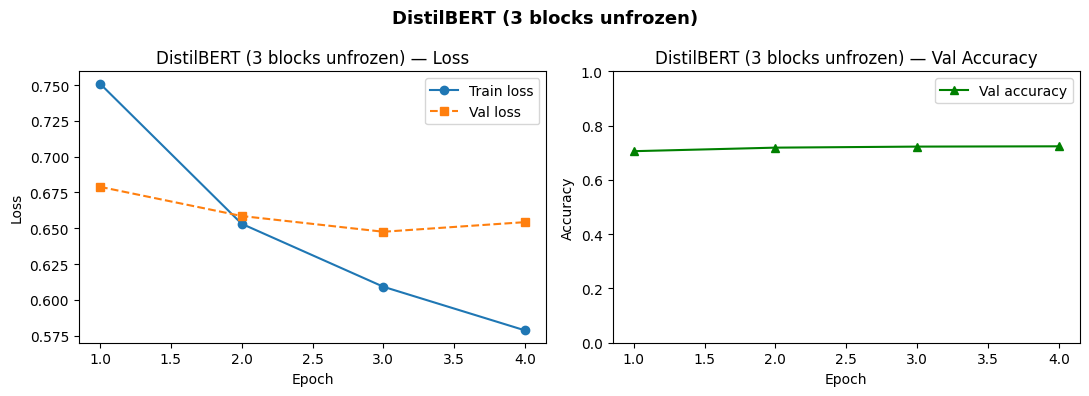

In [6]:
plot_training_history(history, model_name="DistilBERT (3 blocks unfrozen)")


## 4. Rebuild the model on the driver and save it

Exactly the lab pattern: after `TorchDistributor.run()` returns the `state_dict`, we rebuild the model on the driver with `load_state_dict`.

We then persist the model and tokenizer with `save_pretrained` so the `predict_batch_udf` workers.


In [ ]:
# Rebuild the architecture and load the trained weights
dl_model = DistilBertForSequenceClassification.from_pretrained(
    PRETRAINED, num_labels=3
)
dl_model.load_state_dict(state_dict)
dl_model.eval()

# Persist model + tokenizer with the HuggingFace idiom (config + weights)
dl_model.save_pretrained(MODEL_DIR)
DistilBertTokenizerFast.from_pretrained(PRETRAINED).save_pretrained(TOKENIZER_DIR)

print(f"Model saved      -> {MODEL_DIR}")
print(f"Tokenizer saved  -> {TOKENIZER_DIR}")


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved      -> /teamspace/studios/this_studio/project/data/youtube-comment-sentiment/distilbert_finetuned
Tokenizer saved  -> /teamspace/studios/this_studio/project/data/youtube-comment-sentiment/distilbert_tokenizer


## 5. Inference with predict_batch_udf

Inference stays fully inside Spark - nothing is collected to the driver here.

In [ ]:
def make_distilbert_fn():
    """Called once per worker: loads tokenizer + fine-tuned model from disk."""

    tokenizer = DistilBertTokenizerFast.from_pretrained(TOKENIZER_DIR)
    model     = DistilBertForSequenceClassification.from_pretrained(MODEL_DIR)
    model.eval()

    def predict(texts: np.ndarray) -> np.ndarray:
        enc = tokenizer(
            texts.tolist(),
            max_length=MAX_LEN,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        with torch.no_grad():
            logits = model(
                input_ids=enc["input_ids"],
                attention_mask=enc["attention_mask"],
            ).logits
        return logits.argmax(dim=1).numpy()

    return predict


sentiment_udf = predict_batch_udf(
    make_distilbert_fn,
    return_type=IntegerType(),
    batch_size=32,
)

# Load the test split back into Spark and score it in parallel
test_df = (
    spark.read.parquet(TEST_PATH)
    .repartition(4)
    .withColumn("prediction", sentiment_udf(F.col("text")))
    .cache()
)
test_df.show(10, truncate=80)


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 3841.85it/s]


+--------------------------------------------------------------------------------+--------+----------+
|                                                                            text|label_id|prediction|
+--------------------------------------------------------------------------------+--------+----------+
|                   chirality is honestly a subject matter not for the sub 80 iqs|       0|         0|
|       wow getting ruby and rails installed on windows is incredibly challenging|       0|         0|
|                  i think we can all agree that prosecuter is a complete jackass|       2|         2|
|                                                            this is now outdated|       0|         0|
|                                               congratulation mr president trump|       2|         2|
|                             i truly hope this doesn t end up like doofenshmirtz|       0|         0|
|                   do these qualify for federal rebates where they are o

## 6. Evaluation

We evaluate in three steps, preferring big-data-safe Spark operations and falling back to sklearn only for the visual confusion matrix.

- **6.1** Aggregate metrics with `MulticlassClassificationEvaluator` (distributed).
- **6.2** Per-class breakdown with Spark SQL (the lab's Shakespeare pattern: score rows with a UDF, then analyse the results with SQL).
- **6.3** Confusion matrix with sklearn (driver-only, flagged below).

### 6.1 Aggregate metrics (big-data-safe)

`MulticlassClassificationEvaluator` runs distributed across the cluster, so it scales to any test-set size - the correct choice over sklearn for the headline metrics.

In [ ]:
# Both columns must be numeric for the evaluator
eval_df = test_df.select(
    F.col("label_id").cast("double").alias("label"),
    F.col("prediction").cast("double").alias("prediction"),
)

for metric in ("accuracy", "f1", "weightedPrecision", "weightedRecall"):
    score = MulticlassClassificationEvaluator(
        labelCol="label", predictionCol="prediction", metricName=metric
    ).evaluate(eval_df)
    print(f"{metric:>18}: {score:.4f}")


          accuracy: 0.7245
                f1: 0.7245
 weightedPrecision: 0.7259
    weightedRecall: 0.7245


### 6.2 Per-class breakdown with Spark SQL

We reuse the idea from the lab: register the scored predictions as a view and compute per-class recall (how often each true sentiment was predicted correctly) in pure SQL - fully distributed.

In [10]:
# Map numeric ids back to readable labels for the report
label_map = F.create_map(
    [x for i, name in enumerate(LABEL_NAMES) for x in (F.lit(i), F.lit(name))]
)

scored = (
    test_df
    .withColumn("true_label", label_map[F.col("label_id")])
    .withColumn("pred_label", label_map[F.col("prediction")])
)
scored.createOrReplaceTempView("scored")

spark.sql("""
    SELECT
        true_label,
        COUNT(*)                                                   AS support,
        SUM(CASE WHEN true_label = pred_label THEN 1 ELSE 0 END)   AS correct,
        ROUND(
            SUM(CASE WHEN true_label = pred_label THEN 1 ELSE 0 END)
            * 100.0 / COUNT(*),
            2
        )                                                          AS recall_pct
    FROM scored
    GROUP BY true_label
    ORDER BY recall_pct DESC
""").show()


+----------+-------+-------+----------+
|true_label|support|correct|recall_pct|
+----------+-------+-------+----------+
|  Negative|  13723|  10512|     76.60|
|  Positive|  13336|   9898|     74.22|
|   Neutral|  13365|   8876|     66.41|
+----------+-------+-------+----------+



### 6.3 Confusion matrix (sklearn)

> **(!) BIG-DATA NOTE:** `.collect()` transfers all test predictions to the driver, and `sklearn.metrics` runs locally on numpy arrays - it is **not** distributed. This is acceptable here only because the test set is a fixed 10% fraction. The headline metrics in 6.1 already came from the distributed `MulticlassClassificationEvaluator`; sklearn is used below purely to render the visual confusion matrix. On a truly large test set this cell would be replaced by a Spark SQL crosstab (`scored.crosstab("true_label", "pred_label")`).

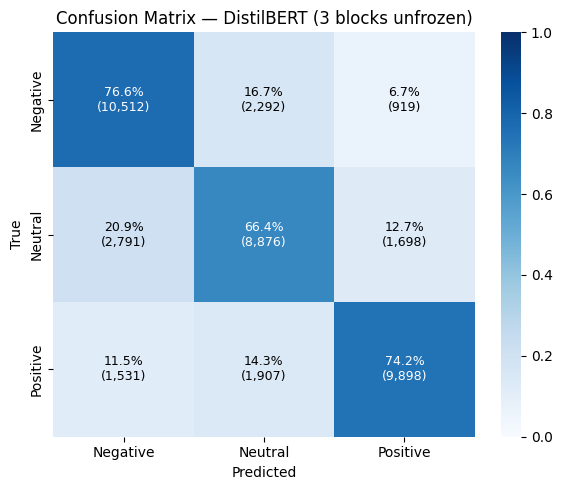

In [ ]:
# (!) BIG-DATA NOTE: see section header - driver-only collect, visual purpose only.
rows   = test_df.select("label_id", "prediction").collect()
y_true = np.array([r["label_id"]   for r in rows])
y_pred = np.array([r["prediction"] for r in rows])

plot_confusion_matrix(y_true, y_pred, model_name="DistilBERT (3 blocks unfrozen)")


In [ ]:
# Collect aggregate metrics from the evaluator results
dl_metrics = {
    "model":     ["DistilBERT (3 blocks unfrozen)"],
    "Accuracy":  [accuracy_score(y_true, y_pred)],
    "F1-score":  [f1_score(y_true, y_pred, average="weighted")],
    "Precision": [precision_score(y_true, y_pred, average="weighted")],
    "Recall":    [recall_score(y_true, y_pred, average="weighted")],
}

dl_metrics_df = pd.DataFrame(dl_metrics).set_index("model")

# Append to the existing model_comparison.csv produced by 02_ml_classification
csv_path = PROJECT_ROOT / "results" / "model_comparison.csv"

if csv_path.exists():
    existing = pd.read_csv(csv_path, index_col=0)
    combined = pd.concat([existing, dl_metrics_df])
else:
    combined = dl_metrics_df

combined.to_csv(csv_path)
print(f"Metrics saved -> {csv_path}")
print(combined)

Metrics saved -> /teamspace/studios/this_studio/project/results/model_comparison.csv
                                Accuracy  F1-score  Precision    Recall
model                                                                  
DistilBERT (2 blocks unfrozen)  0.724471  0.724538   0.725927  0.724471


## 7. Summary

The fine-tuned model and tokenizer were saved in Section 4 with `save_pretrained`.


In [ ]:
print(f"Fine-tuned model -> {MODEL_DIR}")
print(f"Tokenizer        -> {TOKENIZER_DIR}")


Fine-tuned model -> /teamspace/studios/this_studio/project/data/youtube-comment-sentiment/distilbert_finetuned
Tokenizer        -> /teamspace/studios/this_studio/project/data/youtube-comment-sentiment/distilbert_tokenizer
